In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import requests

In [ ]:
df_train = pd.read_csv('/content/train_preprocess.csv')
df_test = pd.read_csv('/content/test_preprocess.csv')
df_valid = pd.read_csv('/content/valid_preprocess.csv')

# **1. EDA**

In [ ]:
print("Total Dataset")
print(f"Train: {len(df_train)}")
print(f"Valid: {len(df_valid)}")
print(f"Test: {len(df_test)}")

Total Dataset
Train: 3521
Valid: 440
Test: 440


In [ ]:
print("Train Dataset missing value")
display(df_train.isna().sum())

print("Valid Dataset missing value")
display(df_valid.isna().sum())

print("Test Dataset missing value")
display(df_test.isna().sum())

Train Dataset missing value


,0
label,0
tweet,0


Test Dataset missing value


,0
label,0
tweet,0


Valid Dataset missing value


,0
label,0
tweet,0



Class Distribution
         Train (%)  Valid (%)  Test (%)
label                                  
anger        25.02      25.00     25.00
happy        23.12      23.18     22.95
sadness      22.66      22.50     22.73
fear         14.74      14.77     14.77
love         14.46      14.55     14.55
---------------------------------------------


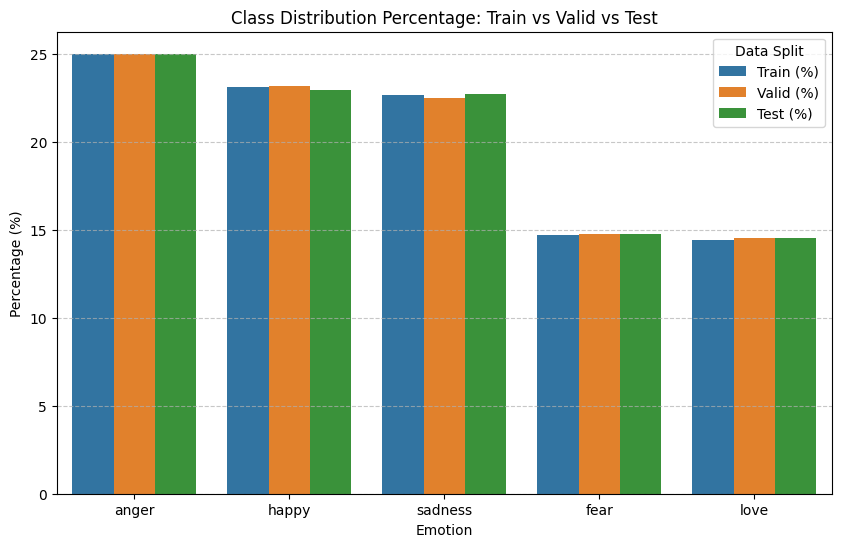

In [ ]:
print("\nClass Distribution")

train_labels = df_train['label']
valid_labels = df_valid['label']
test_labels  = df_test['label']

df_dist = pd.DataFrame({
    'Train (%)': train_labels.value_counts(normalize=True) * 100,
    'Valid (%)': valid_labels.value_counts(normalize=True) * 100,
    'Test (%)':  test_labels.value_counts(normalize=True) * 100
}).fillna(0)

df_dist = df_dist.sort_values(by='Train (%)', ascending=False)

print(df_dist.round(2))
print("-" * 45)

df_dist.index.name = 'Emotion'
df_dist_reset = df_dist.reset_index()

df_melted = df_dist_reset.melt(id_vars='Emotion', var_name='Split', value_name='Percentage')

plt.figure(figsize=(10, 6))

sns.barplot(data=df_melted, x='Emotion', y='Percentage', hue='Split')

plt.title('Class Distribution Percentage: Train vs Valid vs Test')
plt.ylabel('Percentage (%)')
plt.xlabel('Emotion')
plt.legend(title='Data Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Tweet Length Distribution
Mean Length  : 27.81 words
Max Length   : 79 words
90%          : 40.0 words
95%          : 43.0 words


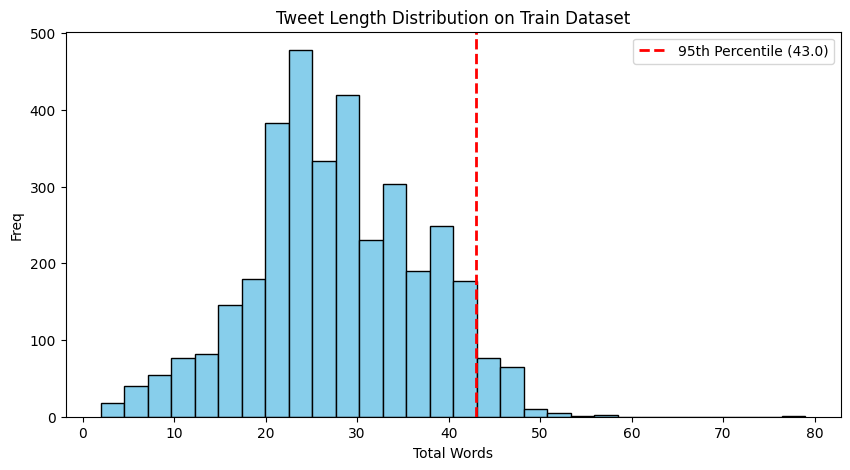

In [ ]:
# Clean
def clean_for_eda(text):
    text = str(text).lower()
    text = re.sub(r'\[username\]|\[url\]', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

df_train['cleaned_text'] = df_train['tweet'].apply(clean_for_eda)

# 1. Tweet Length Distribution
print("\nTweet Length Distribution")
df_train['word_count'] = df_train['cleaned_text'].apply(lambda x: len(x.split()))

percentile_90 = np.percentile(df_train['word_count'], 90)
percentile_95 = np.percentile(df_train['word_count'], 95)
max_len = df_train['word_count'].max()

print(f"Mean Length  : {df_train['word_count'].mean():.2f} words")
print(f"Max Length   : {max_len} words")
print(f"90%          : {percentile_90} words")
print(f"95%          : {percentile_95} words")

# Visualization
plt.figure(figsize=(10, 5))
plt.hist(df_train['word_count'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(percentile_95, color='red', linestyle='dashed', linewidth=2, label=f'95th Percentile ({percentile_95})')
plt.title('Tweet Length Distribution on Train Dataset')
plt.xlabel('Total Words')
plt.ylabel('Freq')
plt.legend()
plt.show()

In [ ]:
# 2. OOV
print("\nOut-Of-Vocabulary (OOV) words")

all_words = ' '.join(df_train['cleaned_text']).split()
word_counts = Counter(all_words)

df_lexicon = pd.read_csv('/content/colloquial-indonesian-lexicon.csv')
valid_words = set(df_lexicon['slang']).union(set(df_lexicon['formal']))

# Word outside df_lexicon
oov_words = {}
for word, count in word_counts.items():
    if word not in valid_words:
        oov_words[word] = count

sorted_oov = sorted(oov_words.items(), key=lambda x: x[1], reverse=True)

print("\nTop 200 OOV words:")
print(f"{'Word':<20} | {'Frequency':<10}")
print("-" * 35)

oov_count = 0
for word, count in sorted_oov:
    if count >= 5: # Filter noise
        print(f"{word:<20} | {count:<10}")
        oov_count += 1
    if oov_count >= 200:
        break


Out-Of-Vocabulary (OOV) words

Top 200 OOV words:
Word                 | Frequency 
-----------------------------------
saat                 | 175       
biar                 | 119       
makan                | 111       
diri                 | 111       
jam                  | 110       
hal                  | 109       
lalu                 | 97        
rasa                 | 93        
tuhan                | 84        
akhirnya             | 82        
oleh                 | 81        
kerja                | 76        
rasanya              | 67        
happy                | 66        
tiap                 | 64        
besar                | 64        
ibu                  | 64        
you                  | 63        
bapak                | 63        
mulai                | 62        
wkwk                 | 61        
i                    | 60        
dunia                | 60        
cerita               | 59        
lupa                 | 58        
negara               | 57    

# **2. Preprocess**

In [ ]:
!pip install Sastrawi pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.3 MB/s eta 0:00:00


In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# 1. Coloquial Lexicon
df_lexicon = pd.read_csv("/content/colloquial-indonesian-lexicon.csv")

merged_lexicon = dict(zip(df_lexicon['slang'], df_lexicon['formal']))

custom_lexicon = {
    "wkwk": "haha", "wkwkwk": "haha", "haha": "haha", "hahaha": "haha",
    "hehe": "hehe", "huhu": "sedih", "happy": "senang", "love": "cinta",
    "dikit": "sedikit", "kesel": "kesal", "mulu": "terus", "yaudah": "ya sudah",
    "doi": "dia", "amp": "", "oldmoneygakngerasain": ""
}

merged_lexicon.update(custom_lexicon)

# 2. Stopword List for Classical (Sastrawi)
factory_stopword = StopWordRemoverFactory()
stopwords_ind_eng = set(factory_stopword.get_stop_words() + ['you', 'i', 'my', 'me', 'the', 'a', 'and', 'of', 'no', 'is', 'on', 'for', 'up'])
stemmer = StemmerFactory().create_stemmer()

# 3. Preprocess
def text_cleaner(text, model_type='bilstm'):
    if pd.isna(text): return ""
    text = str(text).lower()

    # 1. Tag Removal
    text = re.sub(r'\[username\]|\[url\]|#\S+', '', text)

    # 2. Number and Punctuation Removal
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Laugh Normalization
    pola_wkwk = r'\b(?!\b(?:awak|kawak|wak|kaw|wok)\b)(?=[awok]{3,}\b)(?=[awok]*w)(?=[awok]*k)[awok]+\b'
    text = re.sub(pola_wkwk, 'haha', text)
    text = re.sub(r'\bha[ha]+\b', 'haha', text)
    text = re.sub(r'\bhe[he]+\b', 'hehe', text)

    # 4. Slang Normalization
    tokens = text.split()
    normal_tokens = [merged_lexicon.get(w, w) for w in tokens]

    if model_type == 'classical': # Stopword Removal & Stemming
        tokens = [w for w in normal_tokens if w not in stopwords_ind_eng]
        merged_tokens = ' '.join(tokens)
        final_text = stemmer.stem(merged_tokens)
    else:
        final_text = ' '.join(normal_tokens)

    return final_text

def process_and_save(df, file_name):
    print(f"Prosecessing {file_name}...")

    df['clean_text_dl'] = df['tweet'].apply(lambda x: text_cleaner(x, model_type='bilstm'))
    df['clean_text_classical'] = df['tweet'].apply(lambda x: text_cleaner(x, model_type='classical'))

    df.to_csv(file_name, index=False)
    print("Success!\n")

In [ ]:
process_and_save(df_train, 'train_cleaned_checkpoint.csv')
process_and_save(df_test, 'test_cleaned_checkpoint.csv')
process_and_save(df_valid, 'valid_cleaned_checkpoint.csv')

Prosecessing train_cleaned_checkpoint.csv...
Success!

Prosecessing test_cleaned_checkpoint.csv...
Success!

Prosecessing valid_cleaned_checkpoint.csv...
Success!

